# Markowitz

In [ ]:
pip install pyportfolioopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.1/220.1 kB 8.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns
from pypfopt import objective_functions
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_ = pd.read_csv('/content/drive/MyDrive/train_with_VV.csv')
test_ = pd.read_csv('/content/drive/MyDrive/test_with_VV.csv')

df = pd.concat([train_, test_]).sort_values(['ticker', 'date']).drop(columns = ['divCash', 'splitFactor', 'Sector',
                                                                                'adjHigh', 'adjLow', 'adjOpen', 'adjVolume'])
df['date'] = pd.to_datetime(df['date'])
df = df[df['date'] > '2020-12-31']

In [ ]:
df

,date,close,high,low,open,volume,adjClose,ticker,target
8429,2021-01-04,118.64,120.0900,117.110,118.94,2030667.0,115.337656,A,3.835131
8430,2021-01-05,119.61,120.3200,118.065,118.48,2343967.0,116.280656,A,2.123568
8431,2021-01-06,122.89,123.8800,118.210,118.69,2428483.0,119.469357,A,0.960208
8432,2021-01-07,126.16,127.4800,124.110,124.33,1775882.0,122.648337,A,-2.362080
8433,2021-01-08,127.06,127.6404,125.850,126.49,1577237.0,123.523285,A,-2.872659
...,...,...,...,...,...,...,...,...,...
44050,2025-03-26,29.42,29.5200,29.200,29.31,1637384.0,29.420000,WY,-13.324269
44051,2025-03-27,29.59,30.0573,29.250,29.50,3197413.0,29.590000,WY,-16.154106
44052,2025-03-28,29.36,29.6200,29.135,29.50,2568929.0,29.360000,WY,-12.908719
44053,2025-03-31,29.28,29.5000,28.920,29.36,3993561.0,29.280000,WY,-11.919399


In [ ]:
df['target'] = df.groupby('ticker')['adjClose'].shift(-20) / df['adjClose'] * 100 - 100
df = df.dropna()

In [ ]:
def train_test_split(df, date_threshold = '2024-04-30'):
    train = df[df['date'] <= date_threshold]
    #.drop(columns = ['date'])
    test = df[df['date'] > date_threshold]
    #.drop(columns = ['date'])
    return train, test

train, test = train_test_split(df)

In [ ]:
df = df.dropna()

# Markowitz (STANDARD MODEL)

In [ ]:
weights_df = []
for date in test['date'].sort_values().unique():

  df_m = df[df['date'] < date].pivot_table(index = 'date', columns = 'ticker', values = 'adjClose')
  mu = expected_returns.mean_historical_return(df_m, frequency = 20) # Average return
  S = risk_models.sample_cov(df_m, frequency = 20) # Covariance matrix

  ef = EfficientFrontier(mu, S)
  ef.efficient_return(target_return=
                      0.01
                      #max(mu)-0.01
                      ) # minimize volatility given return
  '''
  ეს მეთოდი მინიმიზაციას უკეთებს რისკს რის საზომადაც აღებულია კოვარიაციის მატრიცა,
  constraint-ად გაწერილია, რომ საბოლოო weighted return უდრიდეს არსებულ რითურნებს შორის მაქსიმუმს - 0.01

  (სხვა ლოგიკის გაწერაც შეიძლება)
  '''
  weights = ef.clean_weights()

  weights = pd.DataFrame(weights, index = ['weight', 'date']).T

  weights['date'] = date
  weights = weights.reset_index()

  weights_df.append(weights)

weights_df = pd.concat(weights_df)

In [ ]:
df_m

ticker,A,ABT,ADM,AES,AMZN,APA,APD,BA,BAC,BALL,...,TPR,TSN,TXN,TXT,UNH,USB,VLO,WEC,WELL,WY
date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,115.337656,100.549419,44.577859,19.849838,159.3315,13.258431,241.749314,202.72,27.061545,85.311680,...,29.239080,56.049960,143.109647,46.003944,328.597398,38.454774,47.441801,78.421442,54.616476,27.488762
2021-01-05,116.280656,101.793500,45.444924,20.516055,160.9255,14.524131,254.539853,211.63,27.268810,86.129060,...,29.069241,56.005826,144.159459,46.648674,324.178491,38.579843,48.795335,78.169813,54.935663,27.748485
2021-01-06,119.469357,101.581545,47.286319,21.336014,156.9190,15.116586,261.372291,211.03,28.971984,87.127025,...,30.678240,57.691738,144.874037,47.214052,337.783082,40.864450,49.884972,79.158975,57.258637,27.890914
2021-01-07,122.648337,102.567595,46.866195,21.122483,158.1080,15.358954,257.153847,212.71,29.611801,86.186087,...,31.169879,57.029731,148.155802,48.404323,343.198592,41.681573,50.795841,76.581948,56.123749,28.159015
2021-01-08,123.523285,102.853273,46.991339,21.711828,159.1350,14.883194,257.559466,209.90,29.314421,86.081538,...,30.597790,56.517778,150.996469,48.027404,341.656676,41.122928,49.127334,76.312966,55.574037,27.966317
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-25,120.248521,125.015630,46.050000,12.440018,205.7100,20.565822,291.382611,182.59,43.280000,50.380000,...,74.720000,59.950000,182.419915,74.640000,513.430000,43.188530,132.000000,104.310000,148.170000,29.200000
2025-03-26,119.639845,126.020931,47.070000,12.272972,201.1300,20.772564,293.469879,178.55,42.820000,51.310000,...,73.680000,61.590000,182.935534,75.170000,518.200000,43.257711,134.520000,105.800000,149.850000,29.420000
2025-03-27,118.711863,130.738877,48.280000,12.214014,201.3600,20.871012,293.330728,179.11,42.560000,52.060000,...,72.750000,62.380000,179.236962,75.280000,515.720000,42.724031,133.230000,106.220000,149.920000,29.590000


In [ ]:
weights_df = weights_df.reset_index()
weights_df['21day_return'] = test.sort_values(['date', 'ticker']).reset_index()['target']
weights_df['portfolio_return'] = weights_df['weight'] * weights_df['21day_return']
portfolio_returns = weights_df.groupby('date').sum('portfolio_return')
portfolio_returns['month'] = portfolio_returns.index.month

In [ ]:
mu

,0
ticker,
A,0.000225
ABT,0.005133
ADM,0.001395
AES,-0.009101
AMZN,0.003340
APA,0.008404
APD,0.003629
BA,-0.003243
BAC,0.008174


In [ ]:
weights_df

,level_0,index,weight,date,21day_return,portfolio_return
0,0,A,0.00000,2024-05-01,-5.241906,-0.000000
1,1,ABT,0.08416,2024-05-01,-4.280741,-0.360267
2,2,ADM,0.00125,2024-05-01,3.889840,0.004862
3,3,AES,0.00000,2024-05-01,19.812878,0.000000
4,4,AMZN,0.00000,2024-05-01,0.178771,0.000000
...,...,...,...,...,...,...
10115,39,USB,0.00000,2025-04-01,-3.423510,-0.000000
10116,40,VLO,0.06105,2025-04-01,-13.197248,-0.805692
10117,41,WEC,0.15348,2025-04-01,0.578566,0.088798
10118,42,WELL,0.11084,2025-04-01,-1.012001,-0.112170


In [ ]:
weights_df.to_excel('monthly_returns(44tickers, regular).xlsx')

In [ ]:
portfolio_returns

,level_0,weight,21day_return,portfolio_return,month
date,,,,,
2024-05-01,946,1.00000,123.821202,1.065861,5
2024-05-02,946,1.00000,147.427819,1.980620,5
2024-05-03,946,1.00000,121.747085,1.740108,5
2024-05-06,946,0.99999,85.029494,2.747682,5
2024-05-07,946,1.00001,94.183400,2.218329,5
...,...,...,...,...,...
2025-03-26,946,1.00001,-276.139296,-3.796356,3
2025-03-27,946,0.99999,-271.804189,-4.300643,3
2025-03-28,946,1.00000,-202.255717,-4.045000,3


In [ ]:
portfolio_returns.to_excel('portfolio_returns(44tickers, regular).xlsx')

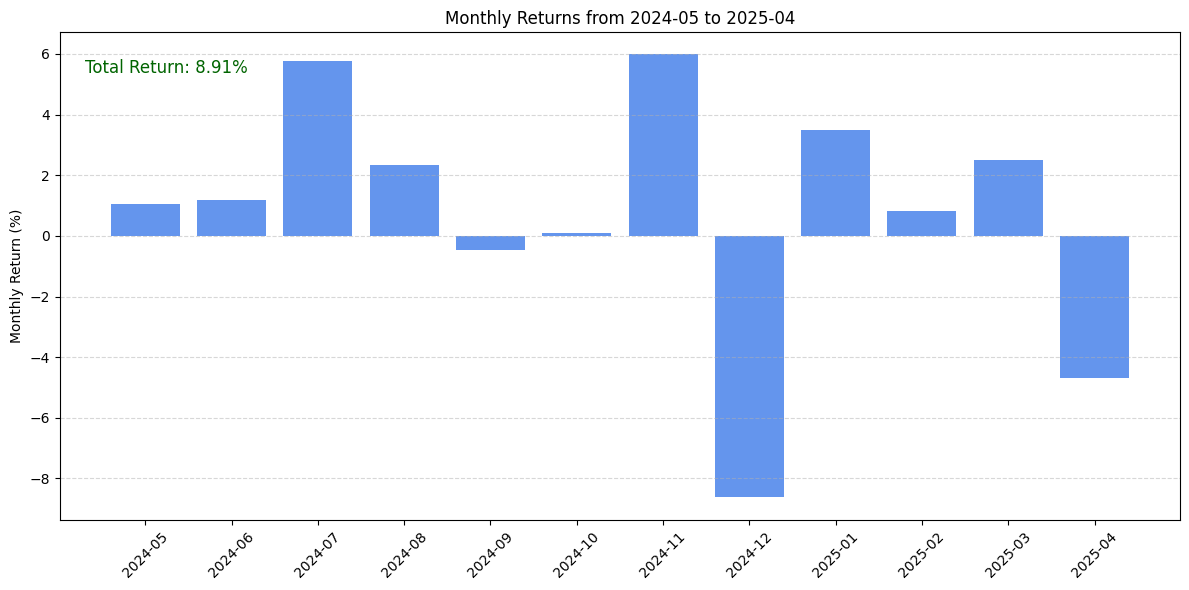

In [ ]:
monthly_return = portfolio_returns.groupby('month').first()['portfolio_return']/100
cumulative_return = np.prod(1 + monthly_return) - 1


monthly_return.index = ['2025-01', '2025-02', '2025-03', '2025-04',
                        '2024-05', '2024-06', '2024-07', '2024-08',
                        '2024-09', '2024-10','2024-11', '2024-12', ]

monthly_return = monthly_return.sort_index()

plt.figure(figsize=(12, 6))
plt.bar(monthly_return.index, monthly_return.values * 100, color='cornflowerblue')
plt.xticks(rotation=45)
plt.ylabel('Monthly Return (%)')
plt.title('Monthly Returns from 2024-05 to 2025-04')

plt.text(-0.7, max(monthly_return.values)*0.9*100,
         f'Total Return: {cumulative_return:.2%}',
         fontsize=12, color='darkgreen')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
excess_returns = monthly_return - 0.004167
sharpe_ratio_monthly = np.mean(excess_returns) / np.std(excess_returns)
sharpe_ratio_annualized = sharpe_ratio_monthly * np.sqrt(12)

In [ ]:
sharpe_ratio_monthly

np.float64(0.04645513982564153)

In [ ]:
sharpe_ratio_annualized

np.float64(0.16092532490145503)

In [ ]:
monthly_return.to_excel('monthly_return (standard).xlsx')

In [ ]:
monthly_return

,portfolio_return
2024-05,0.010659
2024-06,0.011913
2024-07,0.057798
2024-08,0.023474
2024-09,-0.004529
2024-10,0.000905
2024-11,0.059817
2024-12,-0.086274
2025-01,0.035064
2025-02,0.008248


In [ ]:
monthly_return.to_excel('monthly_return (standard).xlsx')

In [ ]:
portfolio_returns.to_excel('portfolio_returns(standard).xlsx')

In [ ]:
portfolio_returns.index

DatetimeIndex(['2024-05-01', '2024-05-02', '2024-05-03', '2024-05-06',
               '2024-05-07', '2024-05-08', '2024-05-09', '2024-05-10',
               '2024-05-13', '2024-05-14',
               ...
               '2025-03-19', '2025-03-20', '2025-03-21', '2025-03-24',
               '2025-03-25', '2025-03-26', '2025-03-27', '2025-03-28',
               '2025-03-31', '2025-04-01'],
              dtype='datetime64[ns]', name='date', length=230, freq=None)

<Axes: xlabel='ticker', ylabel='ticker'>

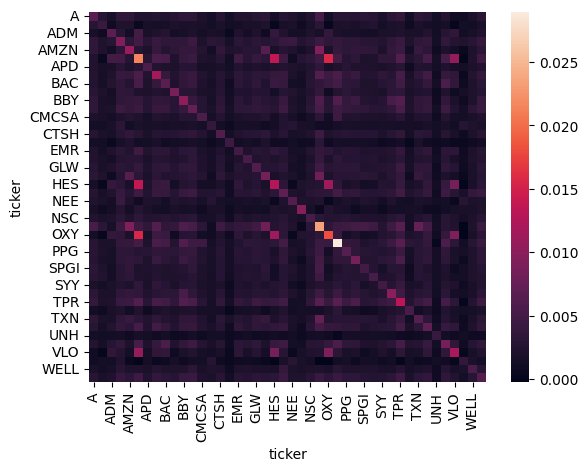

In [ ]:
sns.heatmap(S)

In [ ]:
mu

,0
ticker,
A,0.004156
ABT,0.000817
ADM,0.005989
AES,-0.003967
AMZN,0.002362
APA,0.020819
APD,-0.001210
BA,-0.004737
BAC,0.007284


# Markowitz (SHRINKAGE)

In [ ]:
weights_df = []
for date in test['date'].sort_values().unique():

  df_m = df[df['date'] < date].pivot_table(index = 'date', columns = 'ticker', values = 'adjClose')
  mu = expected_returns.mean_historical_return(df_m, frequency = 20) # Average return
  S = risk_models.CovarianceShrinkage(df_m, frequency = 20).shrunk_covariance() # Covariance matrix

  ef = EfficientFrontier(mu, S)
  ef.efficient_return(target_return=
                      0.01
                      #max(mu)-0.01
                      ) # minimize volatility given return
  '''
  ეს მეთოდი მინიმიზაციას უკეთებს რისკს რის საზომადაც აღებულია კოვარიაციის მატრიცა,
  constraint-ად გაწერილია, რომ საბოლოო weighted return უდრიდეს არსებულ რითურნებს შორის მაქსიმუმს - 0.01

  (სხვა ლოგიკის გაწერაც შეიძლება)
  '''
  weights = ef.clean_weights()

  weights = pd.DataFrame(weights, index = ['weight', 'date']).T

  weights['date'] = date
  weights = weights.reset_index()

  weights_df.append(weights)

weights_df = pd.concat(weights_df)

In [ ]:
weights_df = weights_df.reset_index()
weights_df['21day_return'] = test.sort_values(['date', 'ticker']).reset_index()['target']
weights_df['portfolio_return'] = weights_df['weight'] * weights_df['21day_return']
portfolio_returns = weights_df.groupby('date').sum('portfolio_return')
portfolio_returns['month'] = portfolio_returns.index.month

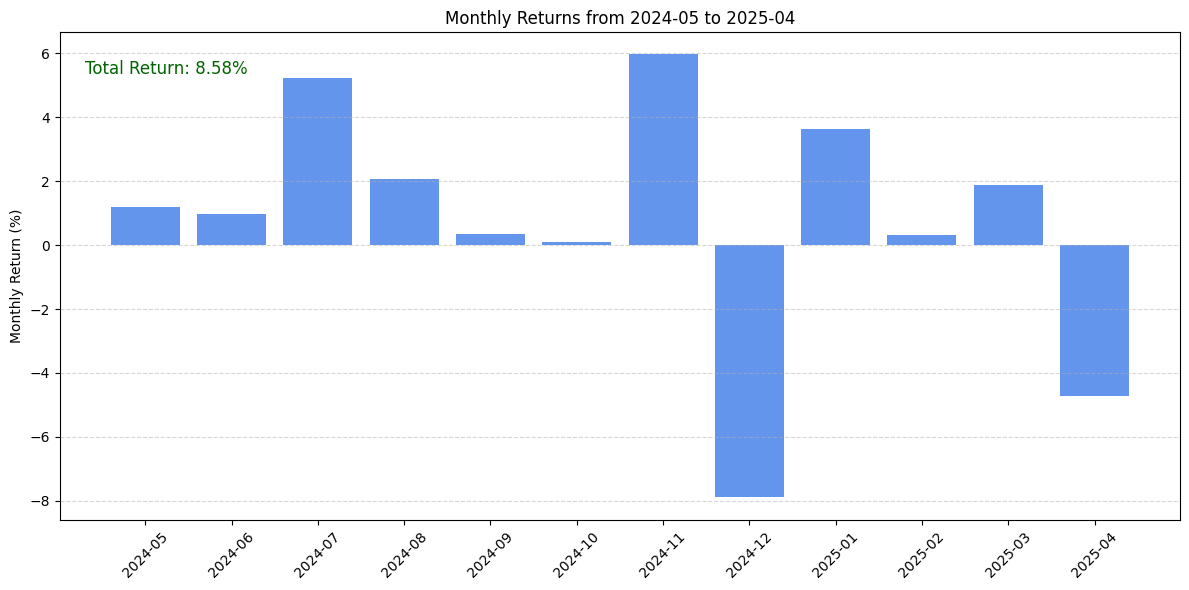

In [ ]:
monthly_return = portfolio_returns.groupby('month').first()['portfolio_return']/100
cumulative_return = np.prod(1 + monthly_return) - 1


monthly_return.index = ['2025-01', '2025-02', '2025-03', '2025-04',
                        '2024-05', '2024-06', '2024-07', '2024-08',
                        '2024-09', '2024-10','2024-11', '2024-12', ]

monthly_return = monthly_return.sort_index()

plt.figure(figsize=(12, 6))
plt.bar(monthly_return.index, monthly_return.values * 100, color='cornflowerblue')
plt.xticks(rotation=45)
plt.ylabel('Monthly Return (%)')
plt.title('Monthly Returns from 2024-05 to 2025-04')

plt.text(-0.7, max(monthly_return.values)*0.9*100,
         f'Total Return: {cumulative_return:.2%}',
         fontsize=12, color='darkgreen')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
monthly_return.to_excel('monthly_return (shrinkage).xlsx')

# Markowitz (ledoit_wolf)

In [ ]:
weights_df = []
for date in test['date'].sort_values().unique():

  df_m = df[df['date'] < date].pivot_table(index = 'date', columns = 'ticker', values = 'adjClose')
  mu = expected_returns.mean_historical_return(df_m, frequency = 20) # Average return
  S = risk_models.CovarianceShrinkage(df_m, frequency = 20).ledoit_wolf() # Covariance matrix

  ef = EfficientFrontier(mu, S)
  ef.efficient_return(target_return=
                      0.01
                      #max(mu)-0.01
                      ) # minimize volatility given return

  weights = ef.clean_weights()

  weights = pd.DataFrame(weights, index = ['weight', 'date']).T

  weights['date'] = date
  weights = weights.reset_index()

  weights_df.append(weights)

weights_df = pd.concat(weights_df)

In [ ]:
weights_df = weights_df.reset_index()
weights_df['21day_return'] = test.sort_values(['date', 'ticker']).reset_index()['target']
weights_df['portfolio_return'] = weights_df['weight'] * weights_df['21day_return']
portfolio_returns = weights_df.groupby('date').sum('portfolio_return')
portfolio_returns['month'] = portfolio_returns.index.month

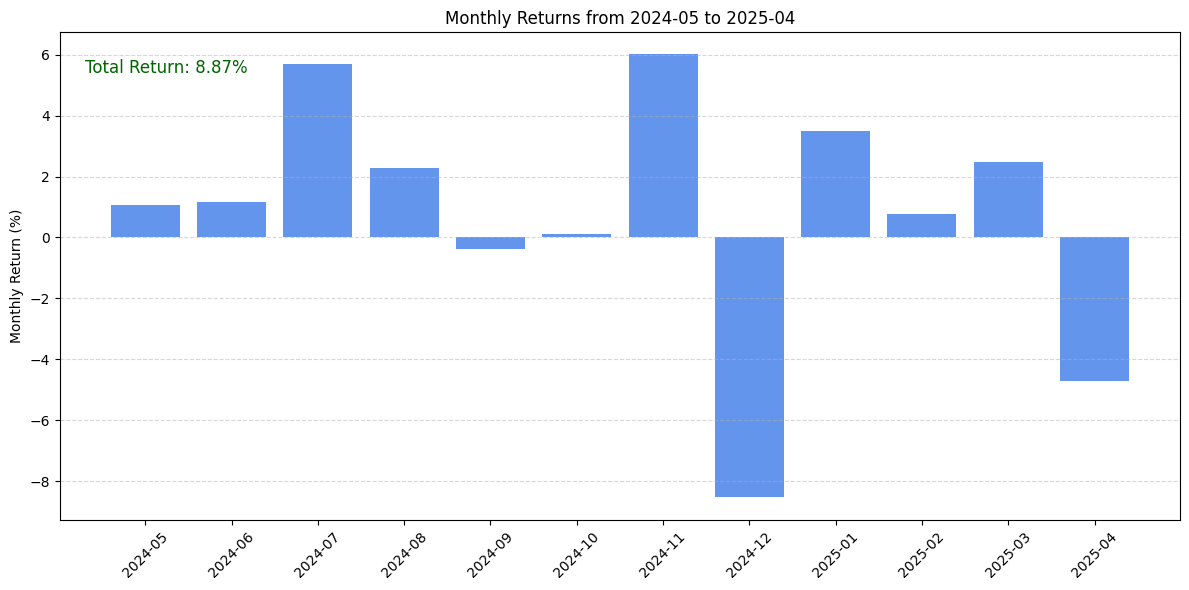

In [ ]:
monthly_return = portfolio_returns.groupby('month').first()['portfolio_return']/100
cumulative_return = np.prod(1 + monthly_return) - 1


monthly_return.index = ['2025-01', '2025-02', '2025-03', '2025-04',
                        '2024-05', '2024-06', '2024-07', '2024-08',
                        '2024-09', '2024-10','2024-11', '2024-12', ]

monthly_return = monthly_return.sort_index()

plt.figure(figsize=(12, 6))
plt.bar(monthly_return.index, monthly_return.values * 100, color='cornflowerblue')
plt.xticks(rotation=45)
plt.ylabel('Monthly Return (%)')
plt.title('Monthly Returns from 2024-05 to 2025-04')

plt.text(-0.7, max(monthly_return.values)*0.9*100,
         f'Total Return: {cumulative_return:.2%}',
         fontsize=12, color='darkgreen')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
monthly_return.to_excel('monthly_return (ledoit wolf).xlsx')

# Markowitz (GARCH)

# Markowitz (ARIMA)

In [ ]:
arima = pd.read_excel('/content/drive/MyDrive/Thesis_Data/ARIMA (1,0,1).xlsx')

In [ ]:
arima

,Unnamed: 0,ticker,forecast_date,pred,target
0,0,A,2024-05-01,-4.639593,-5.241906
1,1,A,2024-05-02,-3.285077,-5.170157
2,2,A,2024-05-03,-2.522973,-5.772678
3,3,A,2024-05-06,-3.028085,-6.941185
4,4,A,2024-05-07,-2.487443,-5.457634
...,...,...,...,...,...
10115,10555,WY,2025-03-26,-2.480411,-13.324269
10116,10556,WY,2025-03-27,-0.624246,-16.154106
10117,10557,WY,2025-03-28,-0.813925,-12.908719
10118,10558,WY,2025-03-31,-1.664058,-11.919399


In [ ]:
weights_df = []
for date in test['date'].sort_values().unique():


  returns = arima[arima['forecast_date'] == date][['ticker','pred']].set_index('ticker')

  df_m = df[df['date'] < date].pivot_table(index = 'date', columns = 'ticker', values = 'adjClose')
  # S = risk_models.sample_cov(df_m, frequency = 20) # Covariance matrix
  S = risk_models.CovarianceShrinkage(df_m, frequency = 20).ledoit_wolf() # Covariance matrix

  ef = EfficientFrontier(np.array(returns), S)

  target_return = 0.10
  ef.efficient_return(target_return=0.1
                      #returns['pred'].max()-0.01
                      #target_return
                      ) # minimize volatility given return
  weights = ef.clean_weights()

  weights = pd.DataFrame(weights, index = ['weight', 'date']).T

  weights['date'] = date
  weights = weights.reset_index()

  weights_df.append(weights)

weights_df = pd.concat(weights_df)

In [ ]:
weights_df

,index,weight,date
0,A,0.00000,2024-05-01
1,ABT,0.10144,2024-05-01
2,ADM,0.02818,2024-05-01
3,AES,0.00000,2024-05-01
4,AMZN,0.00000,2024-05-01
...,...,...,...
39,USB,0.00000,2025-04-01
40,VLO,0.04322,2025-04-01
41,WEC,0.16727,2025-04-01
42,WELL,0.03911,2025-04-01


In [ ]:
weights_df = weights_df.reset_index()
weights_df['21day_return'] = test.sort_values(['date', 'ticker']).reset_index()['target']
weights_df['portfolio_return'] = weights_df['weight'] * weights_df['21day_return']
portfolio_returns = weights_df.groupby('date').sum('portfolio_return')
portfolio_returns['month'] = portfolio_returns.index.month

In [ ]:
portfolio_returns

,level_0,weight,21day_return,portfolio_return,month
date,,,,,
2024-05-01,946,0.99997,123.821202,-0.550023,5
2024-05-02,946,1.00000,147.427819,0.412418,5
2024-05-03,946,0.99999,121.747085,-0.134909,5
2024-05-06,946,1.00000,85.029494,1.064779,5
2024-05-07,946,1.00001,94.183400,0.231318,5
...,...,...,...,...,...
2025-03-26,946,1.00001,-276.139296,-2.181315,3
2025-03-27,946,1.00000,-271.804189,-3.484055,3
2025-03-28,946,1.00001,-202.255717,-3.063823,3


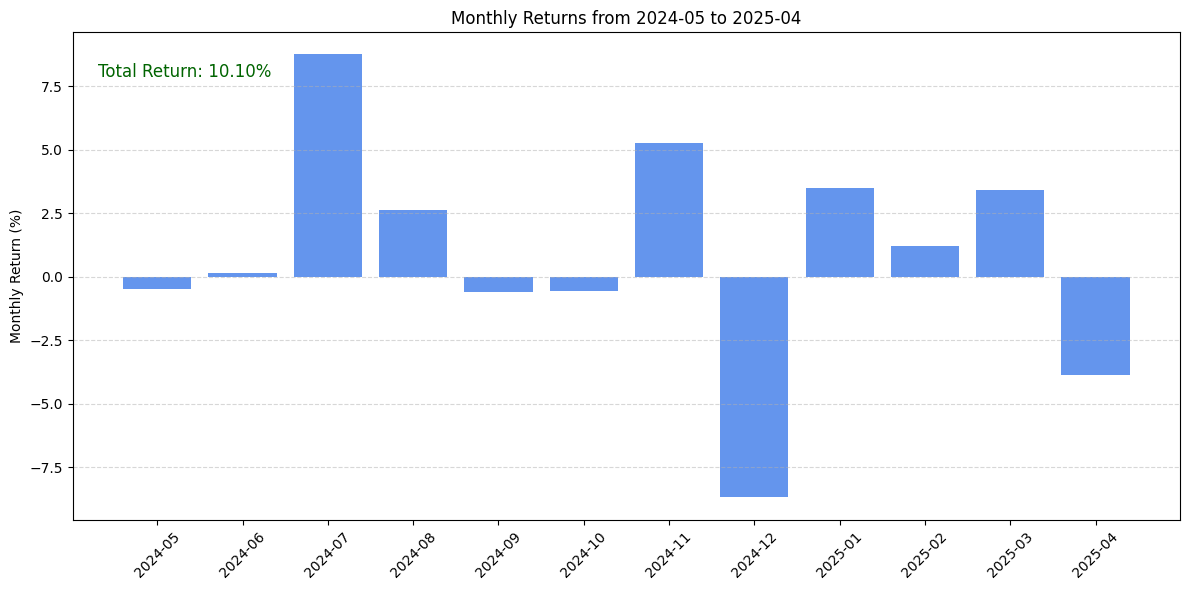

In [ ]:
monthly_return = portfolio_returns.groupby('month').first()['portfolio_return']/100
cumulative_return = np.prod(1 + monthly_return) - 1

monthly_return.index = ['2025-01', '2025-02', '2025-03', '2025-04',
                        '2024-05', '2024-06', '2024-07', '2024-08',
                        '2024-09', '2024-10','2024-11', '2024-12', ]
monthly_return = monthly_return.sort_index()

plt.figure(figsize=(12, 6))
plt.bar(monthly_return.index, monthly_return.values * 100, color='cornflowerblue')
plt.xticks(rotation=45)
plt.ylabel('Monthly Return (%)')
plt.title('Monthly Returns from 2024-05 to 2025-04')

plt.text(-0.7, max(monthly_return.values)*0.9*100,
         f'Total Return: {cumulative_return:.2%}',
         fontsize=12, color='darkgreen')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
excess_returns = monthly_return - 0.004167
sharpe_ratio_monthly = np.mean(excess_returns) / np.std(excess_returns)

In [ ]:
sharpe_ratio_monthly

np.float64(0.11317405515879421)

In [ ]:
sharpe_ratio_annualized = sharpe_ratio_monthly * np.sqrt(12)

In [ ]:
sharpe_ratio_annualized

np.float64(0.39204642726726835)

In [ ]:
monthly_return.to_excel('monthly_return (ARIMA + ledoit_wolf.xlsx')

In [ ]:
weights_df.to_excel('weights_df(ARIMA).xlsx')

In [ ]:
portfolio_returns.to_excel('portfolio_returns(ARIMA).xlsx')

# Markowitz (regular SP500)

In [ ]:
# df = pd.read_excel('/content/drive/MyDrive/Thesis_Data/top10_results.xlsx')
#df = pd.read_excel('/content/drive/MyDrive/Thesis_Data/results.xlsx')
# df = pd.read_excel('/content/drive/MyDrive/Thesis_Data/top10_results (1).xlsx')
df = pd.read_excel('/content/drive/MyDrive/Thesis_Data/top14_results.xlsx')

In [ ]:
df

,date,y_true,y_pred,DGS1MO,DGS1MO_(/12),DGS1MO_PRICE,SP500_adjclose
0,2022-01-03,-0.051831,-0.016474,0.05,0.004074,99.585062,455.745834
1,2022-01-04,-0.042299,-0.013064,0.06,0.004868,99.502488,455.593190
2,2022-01-05,-0.046501,-0.015523,0.05,0.004074,99.585062,446.844809
3,2022-01-06,-0.041116,-0.001530,0.04,0.003274,99.667774,446.425039
4,2022-01-07,-0.040400,-0.005593,0.05,0.004074,99.585062,444.660099
...,...,...,...,...,...,...,...
815,2025-04-03,0.056009,0.002119,4.36,0.150174,73.349633,536.700000
816,2025-04-04,0.115243,0.002119,4.36,0.150174,73.349633,505.280000
817,2025-04-07,0.107895,0.005280,4.36,0.150174,73.349633,504.380000
818,2025-04-08,0.130257,0.005806,4.36,0.150174,73.349633,496.480000


In [ ]:
markowitz_regular = df.iloc[:800-236,]
markowitz_tree = df.iloc[-236:,]

# 238, 236

In [ ]:
markowitz_tree

,date,y_true,y_pred,DGS1MO,DGS1MO_(/12),DGS1MO_PRICE,SP500_adjclose
584,2024-05-01,0.044489,0.008351,5.47,0.168356,68.689181,494.078414
585,2024-05-02,0.044235,0.008304,5.51,0.168957,68.532267,498.699753
586,2024-05-03,0.032291,0.016852,5.51,0.168957,68.532267,504.881288
587,2024-05-06,0.022882,0.020558,5.51,0.168957,68.532267,510.095107
588,2024-05-07,0.033898,0.014164,5.51,0.168957,68.532267,510.657962
...,...,...,...,...,...,...,...
815,2025-04-03,0.056009,0.002119,4.36,0.150174,73.349633,536.700000
816,2025-04-04,0.115243,0.002119,4.36,0.150174,73.349633,505.280000
817,2025-04-07,0.107895,0.005280,4.36,0.150174,73.349633,504.380000
818,2025-04-08,0.130257,0.005806,4.36,0.150174,73.349633,496.480000


In [ ]:
pd.to_datetime(portfolio_dates)

DatetimeIndex(['2024-05-01', '2024-06-03', '2024-07-01', '2024-08-01',
               '2024-09-03', '2024-10-01', '2024-11-01', '2024-12-02',
               '2025-01-02', '2025-02-04', '2025-03-03', '2025-04-01'],
              dtype='datetime64[ns]', freq=None)

In [ ]:
portfolio_dates = pd.to_datetime(portfolio_dates)

['2024-05-01',
 '2024-06-03',
 '2024-07-01',
 '2024-08-01',
 '2024-09-03',
 '2024-10-01',
 '2024-11-01',
 '2024-12-02',
 '2025-01-02',
 '2025-02-04',
 '2025-03-03',
 '2025-04-01']

In [ ]:
weights_df = []
for date in markowitz_tree['date'].sort_values().unique():

  df_m = df[df['date'] < date][['DGS1MO_PRICE', 'SP500_adjclose']]
  mu = expected_returns.mean_historical_return(df_m, frequency = 20) # Average return
  #if date in pd.to_datetime(portfolio_dates):
   # print(mu)
  S = risk_models.sample_cov(df_m, frequency = 20) # Covariance matrix

  ef = EfficientFrontier(mu, S)
  ef.efficient_return(target_return=max(mu)-0.01) # minimize volatility given return

  '''
  ეს მეთოდი მინიმიზაციას უკეთებს რისკს რის საზომადაც აღებულია კოვარიაციის მატრიცა,
  constraint-ად გაწერილია, რომ საბოლოო weighted return უდრიდეს არსებულ რითურნებს შორის მაქსიმუმს - 0.01

  '''
  weights = ef.clean_weights()

  weights = pd.DataFrame(weights, index = ['weight', 'date']).T

  weights['date'] = date
  weights = weights.reset_index()

  weights_df.append(weights)

weights_df = pd.concat(weights_df)



In [ ]:
weights_df = weights_df.pivot_table(index = 'date', columns = 'index', values = 'weight').reset_index()
weights_df = weights_df.merge(markowitz_tree[['y_true', 'DGS1MO_(/12)', 'date']], how = 'left', on = 'date' )
weights_df['portfolio_return'] = 100*weights_df['SP500_adjclose'] * weights_df['y_true']+ weights_df['DGS1MO_PRICE'] * weights_df['DGS1MO_(/12)']
portfolio_returns = weights_df.groupby('date').sum('portfolio_return')
portfolio_returns['month'] = portfolio_returns.index.month

In [ ]:
weights_df

,date,DGS1MO_PRICE,SP500_adjclose,y_true,DGS1MO_(/12),portfolio_return
0,2024-05-01,0.11208,0.88792,0.044489,0.168356,3.969124
1,2024-05-02,0.11210,0.88790,0.044235,0.168957,3.946565
2,2024-05-03,0.11223,0.88777,0.032291,0.168957,2.885649
3,2024-05-06,0.11243,0.88757,0.022882,0.168957,2.049907
4,2024-05-07,0.11256,0.88744,0.033898,0.168957,3.027260
...,...,...,...,...,...,...
231,2025-04-03,0.07362,0.92638,0.056009,0.150174,5.199612
232,2025-04-04,0.07562,0.92438,0.115243,0.150174,10.664192
233,2025-04-07,0.07836,0.92164,0.107895,0.150174,9.955788
234,2025-04-08,0.07836,0.92164,0.130257,0.150174,12.016775


In [ ]:
weights_df['date'] = pd.to_datetime(weights_df['date'])
weights_df.set_index('date', inplace = True)
weights_df['month'] = weights_df.index.month

In [ ]:
len(weights_df[weights_df['month'] == 5])

20

In [ ]:
pd.concat([weights_df.iloc[[0]], weights_df.iloc[[20]]])

,DGS1MO_PRICE,SP500_adjclose,y_true,DGS1MO_(/12),portfolio_return,month
date,,,,,,
2024-05-03,0.11223,0.88777,0.032291,0.168957,2.885649,5
2024-06-03,0.11323,0.88677,0.043546,0.168657,3.880623,6


In [ ]:
portfolio_returns.to_excel('portfolio_returns top14 (regular).xlsx')

In [ ]:
str(weights_df.index[0].date())

'2024-05-03'

In [ ]:
tables_dict = {}
returns_dict = {}
for i in range(len(weights_df[weights_df['month'] == 5])-8):
  tables_list = []
  for j in range(12):
    tables_list.append(weights_df.iloc[i+j*20])

  date = str(weights_df.index[i].date())
  tables_dict[date] = pd.concat(tables_list)
  returns_dict[date] = np.prod(1 + tables_dict[date]['portfolio_return']/100) - 1

In [ ]:
returns_dict

{'2024-05-03': np.float64(0.013025780034911838),
 '2024-05-06': np.float64(0.027896324500771952),
 '2024-05-07': np.float64(0.0415437895126789),
 '2024-05-08': np.float64(0.06157565502913065),
 '2024-05-09': np.float64(0.06314148885663595),
 '2024-05-10': np.float64(0.06328957997051399),
 '2024-05-13': np.float64(0.06883919551765261),
 '2024-05-14': np.float64(0.06488973382876395),
 '2024-05-15': np.float64(0.05969731530922484),
 '2024-05-16': np.float64(0.07537301600107882),
 '2024-05-17': np.float64(0.06829860894398787),
 '2024-05-20': np.float64(0.05834098062615878)}

In [ ]:
final_returns

In [ ]:
portfolio_returns

,DGS1MO_PRICE,SP500_adjclose,y_true,DGS1MO_(/12),portfolio_return,month
date,,,,,,
2024-05-01,0.11208,0.88792,0.044489,0.168356,3.969124,5
2024-05-02,0.11210,0.88790,0.044235,0.168957,3.946565,5
2024-05-03,0.11223,0.88777,0.032291,0.168957,2.885649,5
2024-05-06,0.11243,0.88757,0.022882,0.168957,2.049907,5
2024-05-07,0.11256,0.88744,0.033898,0.168957,3.027260,5
...,...,...,...,...,...,...
2025-04-03,0.07362,0.92638,0.056009,0.150174,5.199612,4
2025-04-04,0.07562,0.92438,0.115243,0.150174,10.664192,4
2025-04-07,0.07836,0.92164,0.107895,0.150174,9.955788,4


In [ ]:
returns = []
for i in range(7):
  temporary_return = []
  for j in range(12):
    temporary_return.append(portfolio_returns.iloc[i+20*j]['portfolio_return'])

  returns.append(np.prod(1 + np.array(temporary_return)/100) - 1)

In [ ]:
import numpy as np
import pandas as pd

months_order = [5,6,7,8,9,10,11,12,1,2,3,4]
returns = []

# Filter once per month in correct order
monthly_grouped = {m: portfolio_returns[portfolio_returns['month'] == m] for m in months_order}

# Iterate 7 times to get 7 portfolios
for i in range(7):
    temp_returns = []
    for m in months_order:
        temp = monthly_grouped[m]
        if i < len(temp):
            temp_returns.append(temp.iloc[i]['portfolio_return'])
        else:
            break  # Not enough data for this portfolio
    if len(temp_returns) == 12:
        total_return = np.prod(1 + np.array(temp_returns)/100) - 1
        returns.append(total_return)

returns


[np.float64(0.11983111636676558),
 np.float64(0.17459345095979084),
 np.float64(0.1690498676054597),
 np.float64(0.16785198509051957),
 np.float64(0.020501486006625935),
 np.float64(0.05217226247831941),
 np.float64(-0.06381215115640859)]

In [ ]:
sum(returns)/len(returns)

np.float64(0.0914554310501532)

In [ ]:
portfolio_returns.groupby('month').first().to_excel('portfolio_returns top14 (regular).xlsx')

In [ ]:
monthly_return.to_excel('monthly_return (regular SP500).xlsx')

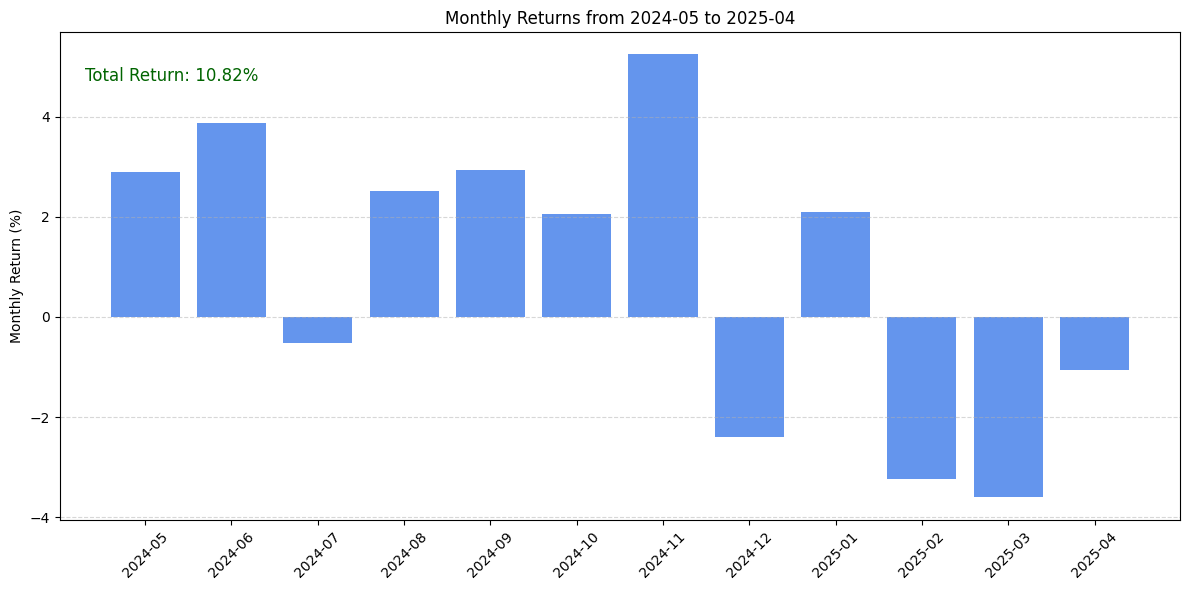

In [ ]:
monthly_return = portfolio_returns.groupby('month').first()['portfolio_return']/100
cumulative_return = np.prod(1 + monthly_return) - 1


monthly_return.index = ['2025-01','2025-02', '2025-03',
                        '2025-04', '2024-05', '2024-06', '2024-07',
                        '2024-08', '2024-09', '2024-10', '2024-11',
                        '2024-12', ]

monthly_return = monthly_return.sort_index()

plt.figure(figsize=(12, 6))
plt.bar(monthly_return.index, monthly_return.values * 100, color='cornflowerblue')
plt.xticks(rotation=45)
plt.ylabel('Monthly Return (%)')
plt.title(f'Monthly Returns from {monthly_return.index.min()} to {monthly_return.index.max()}')

plt.text(-0.7, max(monthly_return.values)*0.9*100,
         f'Total Return: {cumulative_return:.2%}',
         fontsize=12, color='darkgreen')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
excess_returns = monthly_return - 0.004167
sharpe_ratio_monthly = np.mean(excess_returns) / np.std(excess_returns)
sharpe_ratio_annualized = sharpe_ratio_monthly * np.sqrt(12)

In [ ]:
print(sharpe_ratio_monthly)
print(sharpe_ratio_annualized)

0.17114077359197669
0.5928490302158912


In [ ]:
volatility_annual = monthly_return.std() * np.sqrt(12)

In [ ]:
print(volatility_annual)

0.1048297373857605


# Markowitz (tree)

In [ ]:
df['y_pred'] = 100*df['y_pred']
# df = df.set_index('date')

In [ ]:
markowitz_regular = df.iloc[:800-258,]
markowitz_tree = df.iloc[-258:,]

In [ ]:
markowitz_tree

,date,y_true,y_pred,DGS1MO,DGS1MO_(/12),DGS1MO_PRICE,SP500_adjclose
562,2024-04-01,-0.023173,-0.622988,5.49,0.168657,68.610635,515.615039
563,2024-04-02,-0.032496,-0.775896,5.49,0.168657,68.610635,512.336653
564,2024-04-03,-0.036695,-0.641703,5.47,0.168356,68.689181,512.899509
565,2024-04-04,-0.015670,-0.794611,5.47,0.168356,68.689181,506.638977
566,2024-04-05,-0.013772,-1.648753,5.47,0.168356,68.689181,511.931793
...,...,...,...,...,...,...,...
815,2025-04-03,0.056009,0.211942,4.36,0.150174,73.349633,536.700000
816,2025-04-04,0.115243,0.211942,4.36,0.150174,73.349633,505.280000
817,2025-04-07,0.107895,0.527971,4.36,0.150174,73.349633,504.380000
818,2025-04-08,0.130257,0.580613,4.36,0.150174,73.349633,496.480000


In [ ]:
df_m

,DGS1MO_PRICE,SP500_adjclose
0,99.585062,455.745834
1,99.502488,455.593190
2,99.585062,446.844809
3,99.667774,446.425039
4,99.585062,444.660099
...,...,...
795,73.260073,570.993387
796,73.260073,574.193766
797,73.304826,558.899745
798,73.304826,554.253713


In [ ]:
markowitz_tree

,date,y_true,y_pred,DGS1MO,DGS1MO_(/12),DGS1MO_PRICE,SP500_adjclose
543,2024-03-04,0.015934,0.819643,5.51,0.168957,68.532267,504.300988
544,2024-03-05,0.027318,1.759345,5.50,0.168807,68.571429,499.260931
545,2024-03-06,0.009662,1.760477,5.50,0.168807,68.571429,501.790804
546,2024-03-07,0.010182,0.878239,5.51,0.168957,68.532267,506.771797
547,2024-03-08,0.016851,0.349221,5.51,0.168957,68.532267,503.730044
...,...,...,...,...,...,...,...
795,2025-03-06,-0.060059,2.084057,4.38,0.150532,73.260073,570.993387
796,2025-03-07,-0.120018,2.084057,4.38,0.150532,73.260073,574.193766
797,2025-03-10,-0.097548,2.084057,4.37,0.150353,73.304826,558.899745
798,2025-03-11,-0.104237,0.962336,4.37,0.150353,73.304826,554.253713


In [ ]:
portfolio_dates = [ #'2024-04-01',
                    '2024-05-01', '2024-06-03', '2024-07-01',
                    '2024-08-01', '2024-09-03', '2024-10-01',
                    '2024-11-01', '2024-12-02', '2025-01-02',
                    '2025-02-04', '2025-03-03',
                    '2025-04-02',
                    ]

In [ ]:
markowitz_df = markowitz_tree[markowitz_tree['date'].isin(portfolio_dates)]

/tmp/ipython-input-199-1765355510.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  markowitz_df = markowitz_tree[markowitz_tree['date'].isin(portfolio_dates)]


In [ ]:
markowitz_df

,date,y_true,y_pred,DGS1MO,DGS1MO_(/12),DGS1MO_PRICE,SP500_adjclose
584,2024-05-01,0.044489,-0.045461,5.47,0.168356,68.689181,494.078414
606,2024-06-03,0.043546,1.018014,5.49,0.168657,68.610635,521.184345
625,2024-07-01,-0.006125,-0.526822,5.48,0.168507,68.649886,540.244115
647,2024-08-01,0.028250,1.689639,5.55,0.169554,68.376068,537.935888
669,2024-09-03,0.033123,2.365634,5.38,0.166993,69.044879,546.921134
689,2024-10-01,0.023126,1.239746,4.96,0.160390,70.754717,565.036923
712,2024-11-01,0.057071,2.235930,4.75,0.156926,71.641791,567.441674
732,2024-12-02,-0.025846,2.173916,4.75,0.156926,71.641791,599.826313
753,2025-01-02,0.022458,3.105073,4.45,0.151772,72.948328,582.887629
774,2025-02-04,-0.031108,2.273313,4.36,0.150174,73.349633,599.976254


In [ ]:
weights_df = []
for i in range(len(markowitz_df)):
  df_m = markowitz_df.iloc[i][['y_pred', 'DGS1MO_(/12)']]

  date = markowitz_tree['date']
  #portfolio_dates[i]
  #returns = np.array(df_m)
  returns = df_m.rename(index={'y_pred': 'SP500', 'DGS1MO_(/12)': 'TBill'})

  # cov_matrix = risk_models.sample_cov(df_m, frequency = 20, returns_data = True)
  df_m = df.iloc[0 : 800-252+i*20][['DGS1MO_PRICE', 'SP500_adjclose']]
  #S = risk_models.sample_cov(df_m, frequency = 20) # Covariance matrix
  S = risk_models.CovarianceShrinkage(df_m, frequency = 20).ledoit_wolf() # Covariance matrix

  ef = EfficientFrontier(returns, S)

  target_return = 0.003
  ef.efficient_return(target_return=
                      max(0.0001, max(returns) - 0.001)
                      ) # minimize volatility given return
  weights = ef.clean_weights()

  weights = pd.DataFrame(weights, index = ['weight', 'date']).T

  weights['date'] = date
  weights = weights.reset_index()

  weights_df.append(weights)

weights_df = pd.concat(weights_df)

In [ ]:
weights_df = []
for date in markowitz_tree['date'].sort_values().unique():

  df_m = df[df['date'] < date][['DGS1MO_PRICE', 'SP500_adjclose']]
  mu = expected_returns.mean_historical_return(df_m, frequency = 20) # Average return
  #if date in pd.to_datetime(portfolio_dates):
   # print(mu)
  S = risk_models.sample_cov(df_m, frequency = 20) # Covariance matrix

  ef = EfficientFrontier(mu, S)
  ef.efficient_return(target_return=max(mu)-0.01) # minimize volatility given return

  '''
  ეს მეთოდი მინიმიზაციას უკეთებს რისკს რის საზომადაც აღებულია კოვარიაციის მატრიცა,
  constraint-ად გაწერილია, რომ საბოლოო weighted return უდრიდეს არსებულ რითურნებს შორის მაქსიმუმს - 0.01

  '''
  weights = ef.clean_weights()

  weights = pd.DataFrame(weights, index = ['weight', 'date']).T

  weights['date'] = date
  weights = weights.reset_index()

  weights_df.append(weights)

weights_df = pd.concat(weights_df)

In [ ]:
markowitz_tree

,date,y_true,y_pred,DGS1MO,DGS1MO_(/12),DGS1MO_PRICE,SP500_adjclose
562,2024-04-01,-0.023173,-0.622988,5.49,0.168657,68.610635,515.615039
563,2024-04-02,-0.032496,-0.775896,5.49,0.168657,68.610635,512.336653
564,2024-04-03,-0.036695,-0.641703,5.47,0.168356,68.689181,512.899509
565,2024-04-04,-0.015670,-0.794611,5.47,0.168356,68.689181,506.638977
566,2024-04-05,-0.013772,-1.648753,5.47,0.168356,68.689181,511.931793
...,...,...,...,...,...,...,...
815,2025-04-03,0.056009,0.211942,4.36,0.150174,73.349633,536.700000
816,2025-04-04,0.115243,0.211942,4.36,0.150174,73.349633,505.280000
817,2025-04-07,0.107895,0.527971,4.36,0.150174,73.349633,504.380000
818,2025-04-08,0.130257,0.580613,4.36,0.150174,73.349633,496.480000


In [ ]:
weights_df = []
for i in range(len(markowitz_tree)):
  df_m = markowitz_tree.iloc[i][['y_pred', 'DGS1MO_(/12)']]

  date = markowitz_tree.iloc[i]['date']
  #portfolio_dates[i]
  #returns = np.array(df_m)
  returns = df_m.rename(index={'y_pred': 'SP500', 'DGS1MO_(/12)': 'TBill'})

  # cov_matrix = risk_models.sample_cov(df_m, frequency = 20, returns_data = True)
  df_m = df.iloc[0 : 800-252+i*20][['DGS1MO_PRICE', 'SP500_adjclose']]
  #S = risk_models.sample_cov(df_m, frequency = 20) # Covariance matrix
  S = risk_models.CovarianceShrinkage(df_m, frequency = 20).ledoit_wolf() # Covariance matrix

  ef = EfficientFrontier(returns, S)

  target_return = 0.003
  ef.efficient_return(target_return=
                      max(0.0001, max(returns) - 0.001)
                      ) # minimize volatility given return
  weights = ef.clean_weights()

  weights = pd.DataFrame(weights, index = ['weight', 'date']).T

  weights['date'] = date
  weights = weights.reset_index()

  weights_df.append(weights)

weights_df = pd.concat(weights_df)

In [ ]:
weights_df = weights_df.pivot_table(index = 'date', columns = 'index', values = 'weight').reset_index()
weights_df['date'] = pd.to_datetime(weights_df['date'])
markowitz_tree['date'] = pd.to_datetime(markowitz_tree['date'])
weights_df = weights_df.merge(markowitz_tree[['y_true', 'DGS1MO_(/12)', 'y_pred', 'date']], how = 'left', on = 'date' )


/tmp/ipython-input-53-3572606008.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  markowitz_tree['date'] = pd.to_datetime(markowitz_tree['date'])


In [ ]:
weights_df['portfolio_return'] = 100*weights_df['SP500'] * weights_df['y_true'] + weights_df['TBill'] * weights_df['DGS1MO_(/12)']
portfolio_returns = weights_df.groupby('date').sum('portfolio_return')
portfolio_returns.index = pd.to_datetime(portfolio_returns.index)
portfolio_returns['month'] = portfolio_returns.index.month

In [ ]:
weights_df

,date,SP500,TBill,y_true,DGS1MO_(/12),y_pred,portfolio_return
0,2024-04-01,0.00191,0.99809,-0.023173,0.168657,-0.355757,0.163909
1,2024-05-01,0.99206,0.00794,0.044489,0.168356,0.294274,4.414898
2,2024-06-03,0.99924,0.00076,0.043546,0.168657,1.485962,4.351415
3,2024-07-01,0.99709,0.00291,-0.006125,0.168507,0.512644,-0.610189
4,2024-08-01,0.99934,0.00066,0.028250,0.169554,1.691689,2.823241
5,2024-09-03,0.00303,0.99697,0.033123,0.166993,-0.163381,0.176524
6,2024-10-01,0.99941,0.00059,0.023126,0.160390,1.850297,2.311347
7,2024-11-01,0.99965,0.00035,0.057071,0.156926,3.054003,5.705188
8,2024-12-02,0.99946,0.00054,-0.025846,0.156926,1.992763,-2.583101
9,2025-01-02,0.99958,0.00042,0.022458,0.151772,2.537616,2.244947


In [ ]:
weights_df

,date,SP500,TBill,y_true,DGS1MO_(/12),y_pred,portfolio_return
0,2024-04-01,0.00126,0.99874,-0.023173,0.168657,-0.622988,0.165525
1,2024-04-02,0.00106,0.99894,-0.032496,0.168657,-0.775896,0.165034
2,2024-04-03,0.00123,0.99877,-0.036695,0.168356,-0.641703,0.163636
3,2024-04-04,0.00104,0.99896,-0.015670,0.168356,-0.794611,0.166552
4,2024-04-05,0.00055,0.99945,-0.013772,0.168356,-1.648753,0.167506
...,...,...,...,...,...,...,...
253,2025-04-03,0.98381,0.01619,0.056009,0.150174,0.211942,5.512647
254,2025-04-04,0.98381,0.01619,0.115243,0.150174,0.211942,11.340156
255,2025-04-07,0.99735,0.00265,0.107895,0.150174,0.527971,10.761290
256,2025-04-08,0.99768,0.00232,0.130257,0.150174,0.580613,12.995830


In [ ]:
portfolio_returns

,SP500,TBill,y_true,DGS1MO_(/12),y_pred,portfolio_return,month
date,,,,,,,
2024-05-02,0.99849,0.00151,0.044235,0.168957,0.830383,4.417075,5
2024-06-04,0.99936,0.00064,0.047032,0.168507,1.722486,4.700343,6
2024-07-02,0.00135,0.99865,0.003279,0.168507,-0.570573,0.168722,7
2024-08-01,0.99954,0.00046,0.028250,0.169554,2.339028,2.823773,8
2024-09-03,0.03145,0.96855,0.033123,0.166993,0.135199,0.265914,9
2024-10-01,0.99954,0.00046,0.023126,0.160390,2.352987,2.311626,10
2024-11-01,0.99963,0.00037,0.057071,0.156926,2.831913,5.705077,11
2024-12-02,0.99942,0.00058,-0.025846,0.156926,1.888732,-2.582991,12
2025-01-02,0.99960,0.00040,0.022458,0.151772,2.655932,2.244989,1


In [ ]:
portfolio_returns

,SP500,TBill,y_true,DGS1MO_(/12),y_pred,portfolio_return,month
date,,,,,,,
2024-04-01,0.00126,0.99874,-0.023173,0.168657,-0.622988,0.165525,4
2024-04-02,0.00106,0.99894,-0.032496,0.168657,-0.775896,0.165034,4
2024-04-03,0.00123,0.99877,-0.036695,0.168356,-0.641703,0.163636,4
2024-04-04,0.00104,0.99896,-0.015670,0.168356,-0.794611,0.166552,4
2024-04-05,0.00055,0.99945,-0.013772,0.168356,-1.648753,0.167506,4
...,...,...,...,...,...,...,...
2025-04-03,0.98381,0.01619,0.056009,0.150174,0.211942,5.512647,4
2025-04-04,0.98381,0.01619,0.115243,0.150174,0.211942,11.340156,4
2025-04-07,0.99735,0.00265,0.107895,0.150174,0.527971,10.761290,4


In [ ]:
portfolio_returns = portfolio_returns.iloc[-236:]

In [ ]:
import numpy as np
import pandas as pd

months_order = [5,6,7,8,9,10,11,12,1,2,3,4]
returns = []

# Filter once per month in correct order
monthly_grouped = {m: portfolio_returns[portfolio_returns['month'] == m] for m in months_order}

# Iterate 7 times to get 7 portfolios
for i in range(7):
    temp_returns = []
    for m in months_order:
        temp = monthly_grouped[m]
        if i < len(temp):
            temp_returns.append(temp.iloc[i]['portfolio_return'])
        else:
            break  # Not enough data for this portfolio
    print(temp_returns)
    if len(temp_returns) == 12:
        total_return = np.prod(1 + np.array(temp_returns)/100) - 1
        returns.append(total_return)

returns


[np.float64(4.442464985939195), np.float64(4.351499055164485), np.float64(0.1674525094465769), np.float64(2.823772512219406), np.float64(0.26591395995123507), np.float64(2.3116264858050886), np.float64(5.705077273258747), np.float64(-2.582991462076772), np.float64(2.2449888695674076), np.float64(-3.495337604900087), np.float64(-3.8862022177818174), np.float64(-1.1251175946306466)]
[np.float64(4.4170752342647255), np.float64(4.700342676953978), np.float64(0.16872194796814718), np.float64(0.2587728597883383), np.float64(3.552467202851445), np.float64(1.9592323237943983), np.float64(5.9822947731826135), np.float64(-2.8672325333119475), np.float64(1.6600398006683363), np.float64(-3.1093691715189977), np.float64(-2.4610109235031645), np.float64(-1.0518088947087687)]
[np.float64(3.227067524629423), np.float64(4.067708115983111), np.float64(0.16636069539579398), np.float64(6.649010022995812), np.float64(3.614916890498917), np.float64(0.14441953467391855), np.float64(5.366495230195041), np.flo

[np.float64(0.11190314031888993),
 np.float64(0.13443182589580105),
 np.float64(0.20881550235832091),
 np.float64(0.23504574874384354),
 np.float64(0.10097541811722066),
 np.float64(0.12789874763136178),
 np.float64(0.01064234348034776)]

In [ ]:
sum(returns)/len(returns)

np.float64(0.13281610379225509)

In [ ]:
portfolio_returns.groupby('month').first().to_excel('portfolio_returns top14 (tree).xlsx')

In [ ]:
monthly_return.to_excel('monthly_return top14 (tree).xlsx')

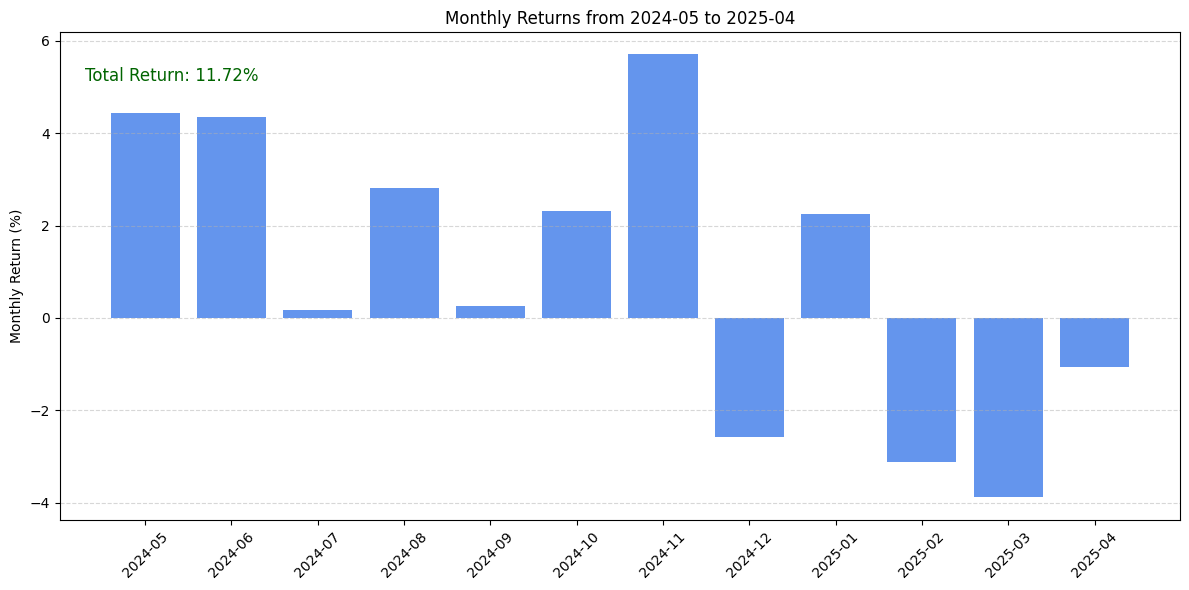

In [ ]:
monthly_return = portfolio_returns.groupby('month').first()['portfolio_return']/100
cumulative_return = np.prod(1 + monthly_return) - 1


monthly_return.index = ['2025-01','2025-02', '2025-03',
                        '2025-04', '2024-05', '2024-06', '2024-07',
                        '2024-08', '2024-09', '2024-10', '2024-11',
                        '2024-12', ]

monthly_return = monthly_return.sort_index()

plt.figure(figsize=(12, 6))
plt.bar(monthly_return.index, monthly_return.values * 100, color='cornflowerblue')
plt.xticks(rotation=45)
plt.ylabel('Monthly Return (%)')
plt.title(f'Monthly Returns from {monthly_return.index.min()} to {monthly_return.index.max()}')

plt.text(-0.7, max(monthly_return.values)*0.9*100,
         f'Total Return: {cumulative_return:.2%}',
         fontsize=12, color='darkgreen')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
excess_returns = monthly_return - 0.004167
sharpe_ratio_monthly = np.mean(excess_returns) / np.std(excess_returns)
sharpe_ratio_annualized = sharpe_ratio_monthly * np.sqrt(12)

In [ ]:
print(sharpe_ratio_monthly)
print(sharpe_ratio_annualized)

0.18320964858156463
0.6346568395602185


In [ ]:
volatility_annual = monthly_return.std() * np.sqrt(12)

In [ ]:
print(volatility_annual)

0.11011687783144612
